<div style="height:60px;line-height:60px;border-radius:5px;background-color:#ab57c3;color:#fff;font-size:42px;font-weight:bolder;text-align:center;">
    Phase 4 - Margin Erosion
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [2]:
df = pd.read_csv('datasets/superstore_cleaned.csv')

In [3]:
df['Cost'] = df['Sales'] - df['Profit']

In [4]:
# ── Simulation function ───────────────────────────────────────────────────────
def simulate_cap(df, cap):
    """
    Simulate profit if all discounts above `cap` are reduced to `cap`.
    Assumes cost per unit is fixed; revenue adjusts proportionally.
    """
    df2        = df.copy()
    needs_cap  = df2['Discount'] > cap
    safe_denom = (1 - df2.loc[needs_cap, 'Discount']).replace(0, np.nan)
    df2.loc[needs_cap,  'Sales_Sim'] = df2.loc[needs_cap, 'Sales'] * (1 - cap) / safe_denom
    df2.loc[~needs_cap, 'Sales_Sim'] = df2.loc[~needs_cap, 'Sales']
    df2['Profit_Sim'] = df2['Sales_Sim'] - df2['Cost']
    return df2['Profit_Sim'].sum(), df2['Profit_Sim']

actual_profit = df['Profit'].sum()
caps          = [0.00, 0.10, 0.15, 0.20, 0.25, 0.30]
sim_profits   = [simulate_cap(df, c)[0] for c in caps]

# Detailed 20% cap simulation
_, df['Profit_Sim'] = simulate_cap(df, 0.20)
df['Profit_Delta']  = df['Profit_Sim'] - df['Profit']

In [5]:
# Sub-category opportunity
sub_opp = df.groupby(['Category', 'Sub-Category']).agg(
    Actual_Profit=('Profit', 'sum'),
    Sim_Profit=('Profit_Sim', 'sum'),
    Profit_Delta=('Profit_Delta', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Rows_Affected=('Profit_Delta', lambda x: (x > 0).sum()),
).reset_index()

sub_opp = sub_opp[sub_opp['Profit_Delta'] > 0].sort_values('Profit_Delta', ascending=False)

In [6]:
# Region opportunity
reg_opp = df.groupby('Region').agg(
    Actual_Profit=('Profit', 'sum'),
    Sim_Profit=('Profit_Sim', 'sum'),
    Profit_Delta=('Profit_Delta', 'sum')
).reset_index().sort_values('Profit_Delta', ascending=False)

In [7]:
# ── Colors ────────────────────────────────────────────────────────────────────
BLUE   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
PURPLE = '#7F77DD'
GRAY   = '#888780'
DARK   = '#2C2C2A'
LIGHT  = '#F8F7F4'
CAT_COLORS = {'Furniture': PURPLE, 'Office Supplies': TEAL, 'Technology': BLUE}
REG_COLORS = {'West': BLUE, 'East': TEAL, 'Central': CORAL, 'South': AMBER}

Saved


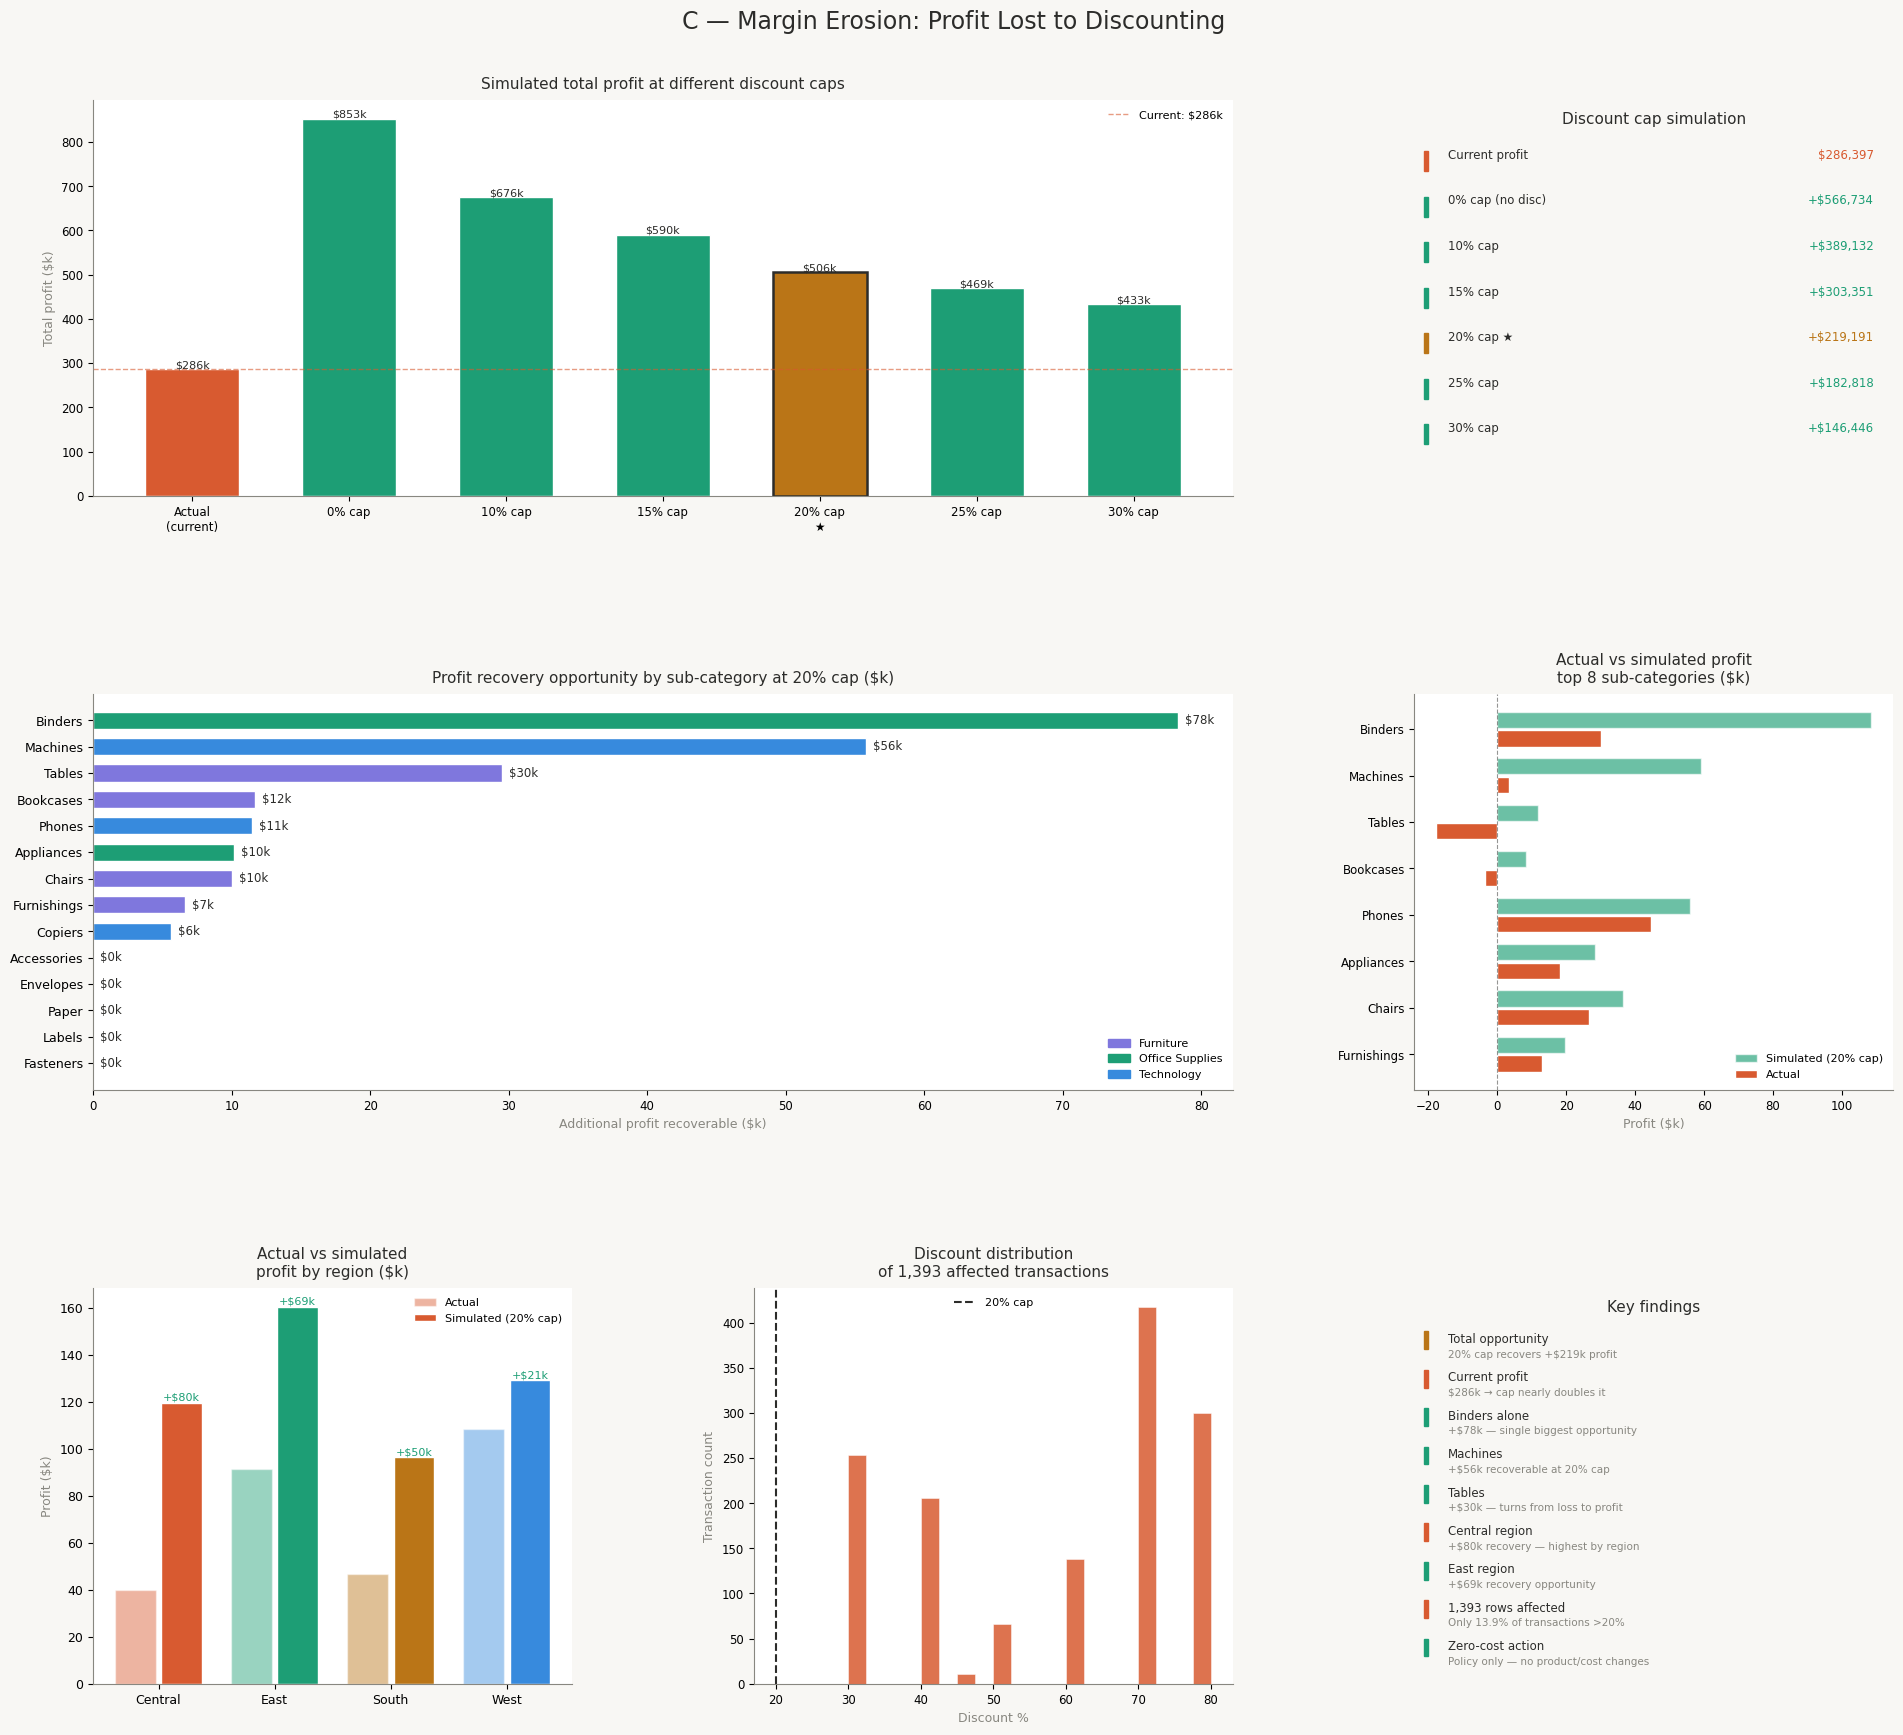

In [8]:
# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor(LIGHT)
plt.suptitle('C — Margin Erosion: Profit Lost to Discounting', fontsize=17,
             fontweight='500', color=DARK, y=0.98)
gs = GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38,
              left=0.07, right=0.97, top=0.93, bottom=0.05)


# ── Chart 1: Simulated profit at each discount cap ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
all_vals   = [actual_profit / 1e3] + [s / 1e3 for s in sim_profits]
all_labels = ['Actual\n(current)', '0% cap', '10% cap',
              '15% cap', '20% cap\n★', '25% cap', '30% cap']
all_colors = [CORAL, TEAL, TEAL, TEAL, AMBER, TEAL, TEAL]
bars1 = ax1.bar(range(len(all_vals)), all_vals, color=all_colors,
                edgecolor='white', width=0.6)
bars1[4].set_edgecolor(DARK); bars1[4].set_linewidth(1.8)
ax1.axhline(actual_profit / 1e3, color=CORAL, linewidth=1,
            linestyle='--', alpha=0.6, label=f'Current: ${actual_profit/1e3:.0f}k')
ax1.set_xticks(range(len(all_vals)))
ax1.set_xticklabels(all_labels, fontsize=8.5)
ax1.set_ylabel('Total profit ($k)', fontsize=9, color=GRAY)
ax1.set_title('Simulated total profit at different discount caps',
              fontsize=11, fontweight='500', color=DARK, pad=8)
ax1.set_facecolor('white')
ax1.tick_params(labelsize=8.5)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(GRAY)
for bar, val in zip(bars1, all_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f'${val:.0f}k', ha='center', fontsize=8, fontweight='500', color=DARK)
ax1.legend(fontsize=8, frameon=False)


# ── Panel 2: Simulation scorecard ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#F1EFE8')
ax2.axis('off')
ax2.text(0.5, 0.97, 'Discount cap simulation', ha='center', va='top',
         fontsize=11, fontweight='500', color=DARK, transform=ax2.transAxes)
rows = [
    ('Current profit',   f'${actual_profit:,.0f}', CORAL),
    ('0% cap (no disc)', '+$566,734',               TEAL),
    ('10% cap',          '+$389,132',               TEAL),
    ('15% cap',          '+$303,351',               TEAL),
    ('20% cap ★',        '+$219,191',               AMBER),
    ('25% cap',          '+$182,818',               TEAL),
    ('30% cap',          '+$146,446',               TEAL),
]
for i, (label, val, color) in enumerate(rows):
    y = 0.85 - i * 0.115
    ax2.add_patch(plt.Rectangle((0.02, y - 0.03), 0.008, 0.05,
                                color=color, transform=ax2.transAxes, clip_on=False))
    ax2.text(0.07, y + 0.01, label, ha='left', va='center', fontsize=8.5,
             fontweight='500', color=DARK, transform=ax2.transAxes)
    ax2.text(0.96, y + 0.01, val, ha='right', va='center', fontsize=8.5,
             fontweight='500', color=color, transform=ax2.transAxes)


# ── Chart 3: Sub-category opportunity ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
colors_sub = [CAT_COLORS.get(c, GRAY) for c in sub_opp['Category']]
bars3 = ax3.barh(sub_opp['Sub-Category'][::-1],
                 sub_opp['Profit_Delta'][::-1] / 1e3,
                 color=colors_sub[::-1], edgecolor='white', height=0.65)
ax3.set_title('Profit recovery opportunity by sub-category at 20% cap ($k)',
              fontsize=11, fontweight='500', color=DARK, pad=8)
ax3.set_xlabel('Additional profit recoverable ($k)', fontsize=9, color=GRAY)
ax3.set_facecolor('white')
ax3.tick_params(axis='y', labelsize=9)
ax3.tick_params(axis='x', labelsize=8.5)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(GRAY)
for bar, val in zip(bars3, sub_opp['Profit_Delta'][::-1] / 1e3):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'${val:.0f}k', va='center', fontsize=8.5, fontweight='500', color=DARK)
patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax3.legend(handles=patches, fontsize=8, frameon=False, loc='lower right')


# ── Chart 4: Actual vs simulated by sub-cat ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
top8 = sub_opp.head(8).reset_index(drop=True)
x4   = np.arange(len(top8))
ax4.barh(x4 + 0.2, top8['Sim_Profit'][::-1] / 1e3, 0.35,
         color=TEAL, alpha=0.65, edgecolor='white', label='Simulated (20% cap)')
ax4.barh(x4 - 0.2, top8['Actual_Profit'][::-1] / 1e3, 0.35,
         color=CORAL, edgecolor='white', label='Actual')
ax4.axvline(0, color=DARK, linewidth=0.8, linestyle='--', alpha=0.5)
ax4.set_yticks(x4)
ax4.set_yticklabels(top8['Sub-Category'][::-1], fontsize=8.5)
ax4.set_title('Actual vs simulated profit\ntop 8 sub-categories ($k)', fontsize=11,
              fontweight='500', color=DARK, pad=8)
ax4.set_xlabel('Profit ($k)', fontsize=9, color=GRAY)
ax4.set_facecolor('white')
ax4.tick_params(labelsize=8.5)
ax4.spines[['top', 'right']].set_visible(False)
ax4.spines[['left', 'bottom']].set_color(GRAY)
ax4.legend(fontsize=8, frameon=False)


# ── Chart 5: Region opportunity ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
x5 = np.arange(len(reg_opp))
ax5.bar(x5 - 0.2, reg_opp['Actual_Profit'] / 1e3, 0.35,
        color=[REG_COLORS.get(r, GRAY) for r in reg_opp['Region']],
        alpha=0.45, edgecolor='white', label='Actual')
ax5.bar(x5 + 0.2, reg_opp['Sim_Profit'] / 1e3, 0.35,
        color=[REG_COLORS.get(r, GRAY) for r in reg_opp['Region']],
        edgecolor='white', label='Simulated (20% cap)')
ax5.set_xticks(x5)
ax5.set_xticklabels(reg_opp['Region'], fontsize=9)
ax5.set_ylabel('Profit ($k)', fontsize=9, color=GRAY)
ax5.set_title('Actual vs simulated\nprofit by region ($k)', fontsize=11,
              fontweight='500', color=DARK, pad=8)
ax5.set_facecolor('white')
ax5.tick_params(labelsize=9)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(GRAY)
ax5.legend(fontsize=8, frameon=False)
for i, (_, row) in enumerate(reg_opp.iterrows()):
    ax5.text(i + 0.2, row['Sim_Profit'] / 1e3 + 1,
             f'+${row["Profit_Delta"]/1e3:.0f}k',
             ha='center', fontsize=8, color=TEAL, fontweight='500')


# ── Chart 6: Discount distribution of affected rows ──────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
affected = df[df['Discount'] > 0.20]
ax6.hist(affected['Discount'] * 100, bins=20, color=CORAL,
         edgecolor='white', linewidth=0.4, alpha=0.85)
ax6.axvline(20, color=DARK, linewidth=1.5, linestyle='--', label='20% cap')
ax6.set_title(f'Discount distribution\nof {len(affected):,} affected transactions',
              fontsize=11, fontweight='500', color=DARK, pad=8)
ax6.set_xlabel('Discount %', fontsize=9, color=GRAY)
ax6.set_ylabel('Transaction count', fontsize=9, color=GRAY)
ax6.set_facecolor('white')
ax6.tick_params(labelsize=8.5)
ax6.spines[['top', 'right']].set_visible(False)
ax6.spines[['left', 'bottom']].set_color(GRAY)
ax6.legend(fontsize=8, frameon=False)


# ── Panel 7: Key findings ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor('#F1EFE8')
ax7.axis('off')
ax7.text(0.5, 0.97, 'Key findings', ha='center', va='top',
         fontsize=11, fontweight='500', color=DARK, transform=ax7.transAxes)
findings = [
    ("Total opportunity",  "20% cap recovers +$219k profit",       AMBER),
    ("Current profit",     "$286k → cap nearly doubles it",         CORAL),
    ("Binders alone",      "+$78k — single biggest opportunity",    TEAL),
    ("Machines",           "+$56k recoverable at 20% cap",          TEAL),
    ("Tables",             "+$30k — turns from loss to profit",     TEAL),
    ("Central region",     "+$80k recovery — highest by region",    CORAL),
    ("East region",        "+$69k recovery opportunity",            TEAL),
    ("1,393 rows affected","Only 13.9% of transactions >20%",       CORAL),
    ("Zero-cost action",   "Policy only — no product/cost changes", TEAL),
]
for i, (name, desc, color) in enumerate(findings):
    y = 0.87 - i * 0.097
    ax7.add_patch(plt.Rectangle((0.02, y - 0.025), 0.008, 0.045,
                                color=color, transform=ax7.transAxes, clip_on=False))
    ax7.text(0.07, y, name, ha='left', va='center', fontsize=8.5,
             fontweight='500', color=DARK, transform=ax7.transAxes)
    ax7.text(0.07, y - 0.038, desc, ha='left', va='center', fontsize=7.5,
             color=GRAY, transform=ax7.transAxes)

plt.savefig('assets/images/margin_erosion.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())

print('Saved')

# Margin Erosion

This is the most actionable output of the entire project — a hard dollar number attached to a single policy change.

**The headline finding: a 20% discount cap would recover `$`219,191 in additional profit — on top of the current `$`286,397 — nearly doubling it to `$`505,588.** This requires no new products, no new customers, no operational changes. Only a pricing policy.

The simulation methodology is straightforward: for every transaction where the actual discount exceeded 20%, we held the cost fixed and recalculated revenue at the capped rate. The difference in profit is the pure opportunity cost of the excessive discount.

**The sub-category breakdown shows where to act first:**

| Sub-category | Recovery at 20% cap | Status change |
|---|---|---|
| Binders | +`$`78k | Loss → profitable |
| Machines | +`$`56k | Near-zero → healthy |
| Tables | +`$`30k | Loss → profitable |
| Bookcases | +`$`12k | Loss → profitable |
| Phones | +`$`11k | Grows margin |
| Appliances | +`$`10k | Grows margin |
| Chairs | +`$`10k | Grows margin |

Three sub-categories — Tables, Bookcases, and Binders — that are currently loss-making in total would flip to profitable simply by capping discounts at 20%.

**Regionally, the Central region has the most to gain (+`$`80k)**, which directly explains why it has the worst margin (7.9%) of any region. It is not a structurally bad market — it is a market being over-discounted at 24% average. The East (+`$`69k) and South (+`$`50k) also have large recoveries, with West having the least (+`$`21k) because it already self-regulates with lower average discounts (11%).

**The 1,393 affected transactions represent just 13.9% of all rows** — meaning 86.1% of the business is already operating within a healthy range. The damage is concentrated, not widespread, which makes it much easier to fix with a targeted policy rather than a broad restructuring.

Ready to move to D — the predictive model (Random Forest feature importance)?

# [C - Margin Erosion](assets/images/margin_erosion.png)